# Housing Market Classification Analysis

## Objective
This project analyzes global housing and economic data to examine how GDP growth relates to housing market trends and to prepare the data for predictive modeling.

## Dataset
- Source: [Kaggle Dataset](https://www.kaggle.com/datasets/atharvasoundankar/global-housing-market-analysis-2015-2024)
- Timeframe: 2015–2024

## Key Questions
- How does GDP growth relate to housing prices?
- Which variables best explain economic performance?
- What features improve predictive modeling?

## Key Findings
- GDP growth is positively related to housing prices  
- Economic growth occurs across a wide range of housing markets  
- GDP to HPI ratio is one of the most important features  
- Feature engineering improved the dataset’s ability to capture patterns

## Setup and Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# loads the data 
df = pd.read_csv('global_housing_market_extended.csv', sep = ',')

display(df.head(5)) # loads the frist 5 rows
print("df shape:", df.shape) # Dimensions 

,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


df shape: (200, 11)


In [3]:
# check for missing values in the data

df.isnull().sum()

Country                  0
Year                     0
House Price Index        0
Rent Index               0
Affordability Ratio      0
Mortgage Rate (%)        0
Inflation Rate (%)       0
GDP Growth (%)           0
Population Growth (%)    0
Urbanization Rate (%)    0
Construction Index       0
dtype: int64

## Exploratory Data Analysis

- Understanding some of the patterns in the data can better inform data cleaning, preprocessing, and feature engineering techniques used to prepare the data for regressors

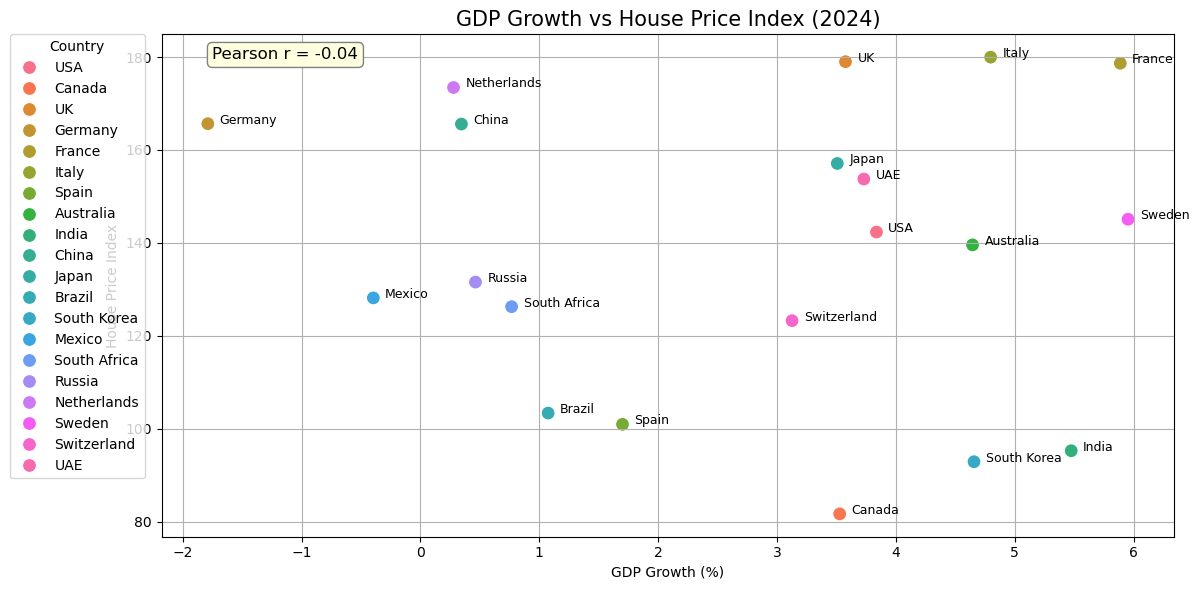

In [4]:
data_2024 = df[df['Year'] == 2024]

corr_coef, p_value = pearsonr(data_2024['GDP Growth (%)'], data_2024['House Price Index'])

plt.figure(figsize = (12, 6))
sns.scatterplot(
    data = data_2024,
    x = 'GDP Growth (%)',
    y = 'House Price Index',
    hue = 'Country',
    s = 100
)

for i in range(data_2024.shape[0]):
    plt.text(
        x = data_2024['GDP Growth (%)'].iloc[i] + 0.1,
        y = data_2024['House Price Index'].iloc[i],
        s = data_2024['Country'].iloc[i],
        fontsize = 9
    )

# Correlation coefficient annotation
plt.text(
    0.05, 0.95,
    f'Pearson r = {corr_coef:.2f}',
    transform = plt.gca().transAxes,
    fontsize = 12,
    bbox = dict(boxstyle = "round,pad=0.3", facecolor = "lightyellow", edgecolor = "gray")
)

# Move legend to the left
plt.legend(
    title = 'Country',
    bbox_to_anchor = (-0.15, 1),
    loc = 'upper left',
    borderaxespad = 0
)

plt.title('GDP Growth vs House Price Index (2024)', fontsize=15)
plt.xlabel('GDP Growth (%)')
plt.ylabel('House Price Index')
plt.grid(True)
plt.tight_layout()
plt.show()

*Observations:* From the scatter plot, we observe a slight positive trend between GDP Growth (%) and House Price Index across countries in 2024, suggesting that stronger economic growth may be associated with higher housing prices.

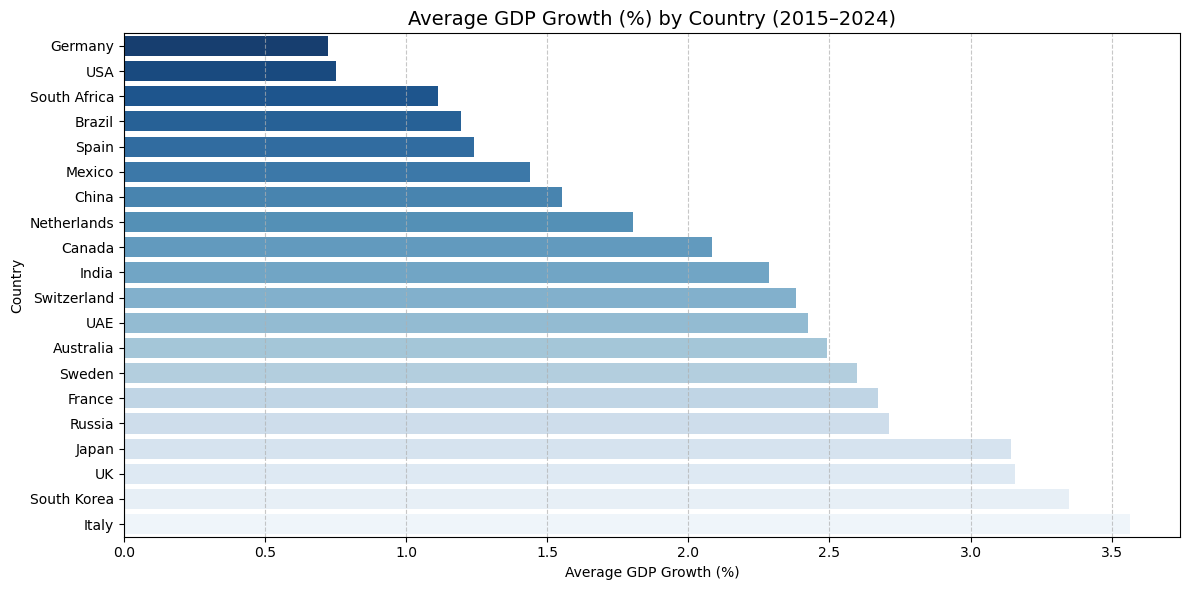

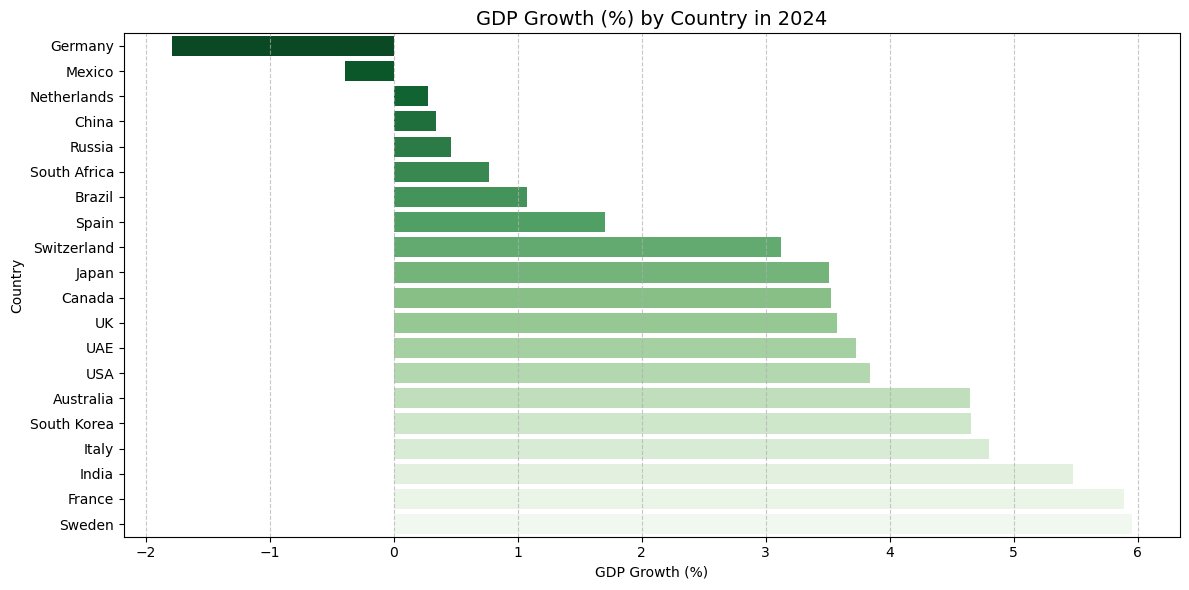

In [5]:
# Calculate average GDP Growth by country across all years
avg_gdp_by_country = df.groupby('Country')['GDP Growth (%)'].mean().sort_values()

plt.figure(figsize = (12, 6))
sns.barplot(
    x = avg_gdp_by_country.values,
    y = avg_gdp_by_country.index,
    hue = avg_gdp_by_country.index,
    palette = 'Blues_r',
    legend = False
)

plt.title('Average GDP Growth (%) by Country (2015–2024)', fontsize = 14)
plt.xlabel('Average GDP Growth (%)')
plt.ylabel('Country')
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

# Filter data for year 2024
year = df[df['Year'] == 2024]

# Sort values for nicer plotting 
gdp_2024 = year[['Country', 'GDP Growth (%)']].sort_values('GDP Growth (%)')

plt.figure(figsize = (12, 6))
sns.barplot(
    x = 'GDP Growth (%)',
    y = 'Country',
    data = gdp_2024,
    hue = 'Country',
    palette = 'Greens_r',
    legend = False
)
plt.title('GDP Growth (%) by Country in 2024', fontsize = 14)
plt.xlabel('GDP Growth (%)')
plt.ylabel('Country')
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

*Observations:* The average GDP growth chart shows each country’s economic strength over time, while the 2024 GDP chart shows current performance. Comparing the two shows which countries are maintaining their growth and which are shifting, helping identify whether the housing market may rise or fall.

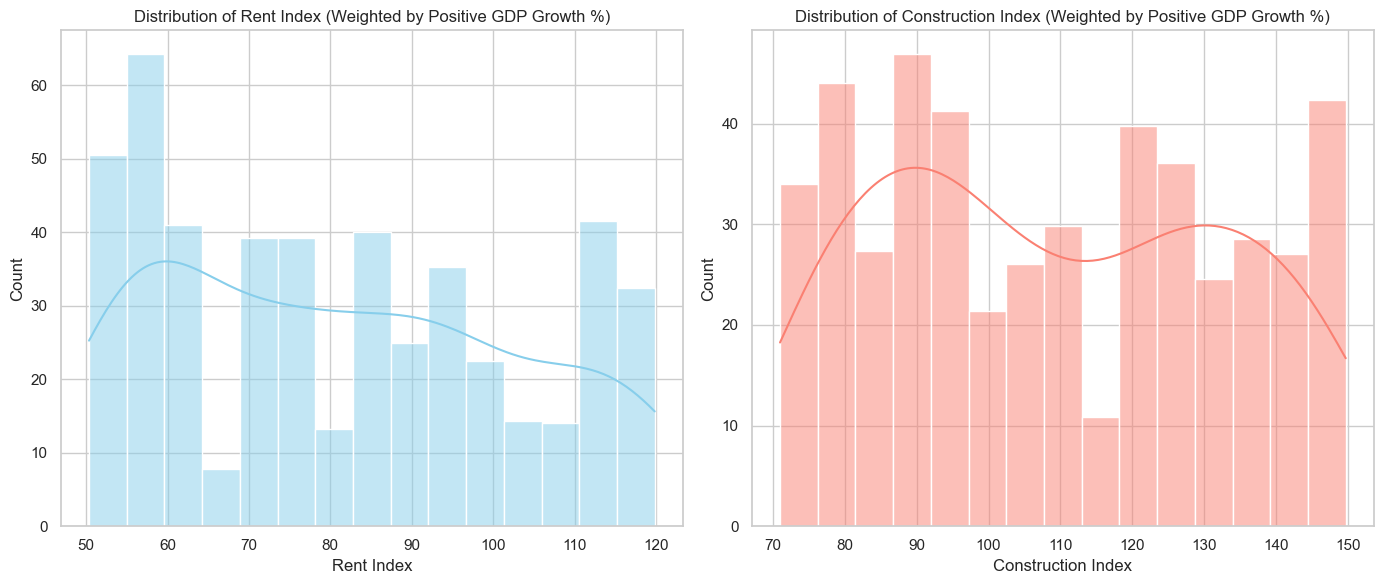

In [6]:
# Replace negative GDP Growth (%) with zero for weighting
df['GDP Growth (Positive)'] = df['GDP Growth (%)'].clip(lower=0)

# Set the style
sns.set(style = 'whitegrid')

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Histogram for Rent Index weighted by positive GDP Growth (%)
sns.histplot(
    data = df,
    x = 'Rent Index',
    weights = 'GDP Growth (Positive)',
    kde = True,
    bins = 15,
    ax = axes[0],
    color = 'skyblue'
)
axes[0].set_title('Distribution of Rent Index (Weighted by Positive GDP Growth %)')

# Histogram for Construction Index weighted by positive GDP Growth (%)
sns.histplot(
    data = df,
    x = 'Construction Index',
    weights = 'GDP Growth (Positive)',
    kde = True,
    bins = 15,
    ax = axes[1],
    color = 'salmon'
)
axes[1].set_title('Distribution of Construction Index (Weighted by Positive GDP Growth %)')

plt.tight_layout()
plt.show()

*Observations:* Positive GDP growth appears across a wide range of Rent and Construction Index values, rather than clustering in one specific range. This suggests that economic growth occurs in both lower and higher cost housing markets, indicating a more broadly distributed relationship between housing conditions and economic performance.

## Categorical Data and Clean Data

- Focusing on recent years (2020–2024)
- Capture housing market–GDP relationships
- GDP to House Price Index(HPI) ratio
- Year on Year House price Growth per country

In [7]:
# Filter for recent years (2020-2024)
recent_data = df[df['Year'].between(2020, 2024)].copy()

# Create a GDP Growth Category safely
recent_data.loc[:, 'GDP Category'] = pd.cut(
    recent_data['GDP Growth (%)'],
    bins=[-float('inf'), 0, 2, 5, float('inf')],
    labels=['Recession', 'Low Growth', 'Moderate Growth', 'High Growth']
)

# Create new engineered features:
# GDP-to-House Price Index Ratio
recent_data['GDP_to_HPI_Ratio'] = recent_data['GDP Growth (%)'] / recent_data['House Price Index']

# Year-on-Year House Price Growth (within each country)
recent_data['House_Price_Growth'] = recent_data.groupby('Country')['House Price Index'].pct_change() * 100

# Regional House Price Averages (if Region column exists — assuming so)
if 'Region' in recent_data.columns:
    regional_avg = recent_data.groupby(['Region', 'Year'])['House Price Index'].mean().reset_index()
    recent_data = recent_data.merge(regional_avg, on=['Region', 'Year'], suffixes=('', '_Regional_Avg'))

    # Difference from Regional Average
    recent_data['HPI_vs_Regional_Avg'] = recent_data['House Price Index'] - recent_data['House Price Index_Regional_Avg']

# Drop rows with NaN values created by pct_change or merging
recent_data.dropna(inplace=True)

# Select relevant columns for housing market–GDP relationship (plus new features)
housing_gdp_data = recent_data[[
    'Country', 'Year', 'GDP Growth (%)', 'GDP Category',
    'House Price Index', 'Rent Index', 'Construction Index',
    'GDP_to_HPI_Ratio', 'House_Price_Growth'
]]

# Include regional difference columns if created
if 'HPI_vs_Regional_Avg' in recent_data.columns:
    housing_gdp_data['HPI_vs_Regional_Avg'] = recent_data['HPI_vs_Regional_Avg']

# Preview the final dataset
housing_gdp_data.head()

,Country,Year,GDP Growth (%),GDP Category,House Price Index,Rent Index,Construction Index,GDP_to_HPI_Ratio,House_Price_Growth
6,USA,2021,0.602643,Low Growth,139.789998,114.531196,136.299001,0.004311,-4.418552
7,USA,2022,-1.403595,Recession,115.675333,69.665416,85.897255,-0.012134,-17.250637
8,USA,2023,-1.407643,Recession,80.552212,107.082300,139.048274,-0.017475,-30.363536
9,USA,2024,3.836849,Moderate Growth,142.329813,73.162862,107.777194,0.026957,76.692619
16,Canada,2021,0.229172,Low Growth,108.484049,52.582086,81.591590,0.002112,-3.415450


## Train/Test Split

- Naive Bayes

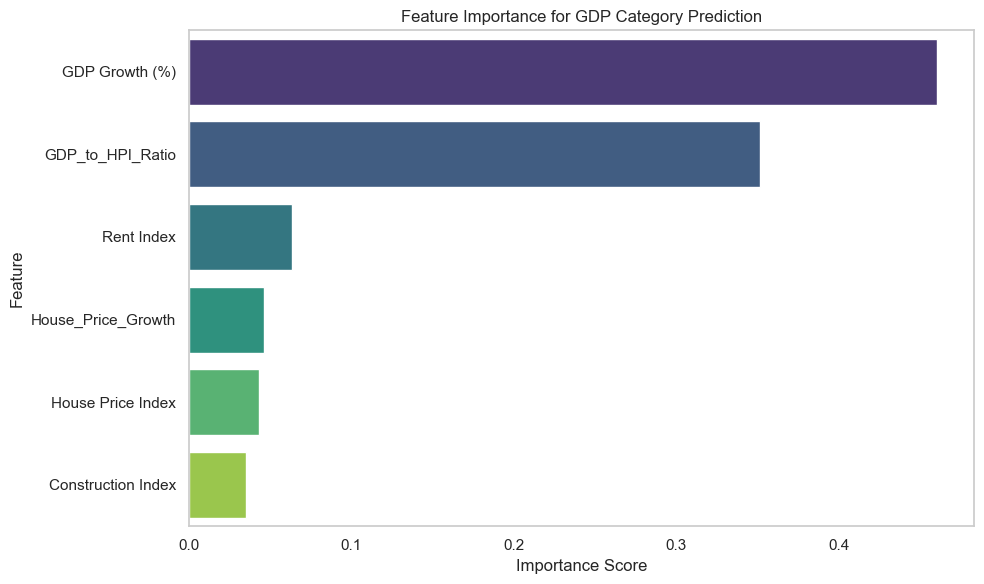

GDP Growth (%)        0.460355
GDP_to_HPI_Ratio      0.351517
Rent Index            0.063655
House_Price_Growth    0.046342
House Price Index     0.043294
dtype: float64

In [8]:
# Prepare data
X = housing_gdp_data.drop(columns=['Country', 'Year', 'GDP Category'])  # Features
y = housing_gdp_data['GDP Category']  # Target

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size = 0.2, random_state = 42, stratify = y_encoded
)

# Fit Random Forest Classifier
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(rf.feature_importances_, index = X.columns).sort_values(ascending = False)

# Plot feature importances
plt.figure(figsize = (10, 6))
sns.barplot(
    x = feature_importances, 
    y = feature_importances.index, 
    hue = feature_importances.index,
    palette = "viridis",
    legend = False
)
plt.title('Feature Importance for GDP Category Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis = 'x')
plt.tight_layout()
plt.show()

# Display top features
feature_importances.head()

*Observations:* This feature importance analysis identifies which housing market variables most strongly influence GDP growth categories between 2020 and 2024. The GDP to HPI ratio shows particularly high importance, suggesting that the relationship between economic growth and housing trends is meaningful and predictive.

## Feature Engineering Plan

In [9]:
# Start fresh with a clean recent dataset
recent_data = df[df['Year'].between(2020, 2024)].copy()

# Create GDP Growth Category safely
recent_data.loc[:, 'GDP Category'] = pd.cut(
    recent_data['GDP Growth (%)'],
    bins=[-float('inf'), 0, 2, 5, float('inf')],
    labels=['Recession', 'Low Growth', 'Moderate Growth', 'High Growth']
)

# Select relevant columns
housing_gdp_data = recent_data[[
    'Country', 'Year', 'GDP Growth (%)', 'GDP Category',
    'House Price Index', 'Rent Index', 'Construction Index'
]].copy()

# Log-transform House Price Index
housing_gdp_data.loc[:, 'Log_House_Price_Index'] = np.log(housing_gdp_data['House Price Index'])

# Bucketizing House Price Index into quantiles
housing_gdp_data.loc[:, 'HPI_Category'] = pd.qcut(
    housing_gdp_data['House Price Index'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Check if 'GDP Category' exists before dummy encoding
if 'GDP Category' in housing_gdp_data.columns:
    housing_gdp_data = pd.get_dummies(housing_gdp_data, columns=['GDP Category'])
else:
    print("GDP Category not found!")

# Create GDP-to-HPI Ratio
housing_gdp_data.loc[:, 'GDP_to_HPI_Ratio'] = housing_gdp_data['GDP Growth (%)'] / housing_gdp_data['House Price Index']

# Preview the final dataset
housing_gdp_data.head()

,Country,Year,GDP Growth (%),House Price Index,Rent Index,Construction Index,Log_House_Price_Index,HPI_Category,GDP Category_Recession,GDP Category_Low Growth,GDP Category_Moderate Growth,GDP Category_High Growth,GDP_to_HPI_Ratio
5,USA,2020,5.756677,146.252228,71.819775,141.586188,4.985333,Medium,False,False,False,True,0.039361
6,USA,2021,0.602643,139.789998,114.531196,136.299001,4.940141,Medium,False,True,False,False,0.004311
7,USA,2022,-1.403595,115.675333,69.665416,85.897255,4.750787,Low,True,False,False,False,-0.012134
8,USA,2023,-1.407643,80.552212,107.082300,139.048274,4.388906,Low,True,False,False,False,-0.017475
9,USA,2024,3.836849,142.329813,73.162862,107.777194,4.958147,Medium,False,False,True,False,0.026957


*Note:* Transformed recent housing and GDP data into a richer, cleaner, and model-ready dataset. Engineering new features and categorizing key variables, we made patterns in the housing market and economy easier to detect and predict.

## Conclusion

This analysis shows that GDP growth is meaningfully related to housing market performance. The feature engineering process improved the dataset by making patterns between economic and housing indicators easier to identify. The final dataset is organized in a way that supports predictive modeling and provides clear insight into global housing and economic trends.